# Neural Network Experiments: Tabular MLP, Domain-Constrained, Temporal

Compare three architectures against CatBoost baseline (PR-AUC 0.7144)

In [1]:
import sys
print(sys.executable)

/Users/ansh.patel/forecast_v0/.venv-ml/bin/python


In [2]:
import subprocess
subprocess.run(['/Library/Developer/CommandLineTools/usr/bin/python3', '-m', 'pip', 'install', 'torch', 'matplotlib', 'seaborn', 'scikit-learn', '-q'])


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '-m', 'pip', 'install', 'torch', 'matplotlib', 'seaborn', 'scikit-learn', '-q'], returncode=0)

In [3]:
import numpy as np
import pandas as pd
import pickle
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Load Data & Prepare

In [4]:
# Load data
train_df = pd.read_parquet('dataset/train.parquet')
print(f'Train shape: {train_df.shape}')

# Load feature metadata
with open('models/model_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

features = metadata['features']
categoricals = metadata.get('categoricals', [])
print(f'Features: {len(features)}')
print(f'Categoricals: {categoricals}')

Train shape: (3573, 32)
Features: 16
Categoricals: ['opportunity_type', 'source', 'geo', 'segment']


In [5]:
# Encode categoricals
X = train_df[features].copy()
encoders = {}

for feat in categoricals:
    if feat in X.columns:
        le = LabelEncoder()
        X[feat] = le.fit_transform(X[feat].astype(str))
        encoders[feat] = le

y = train_df['is_won'].values.astype(np.float32)

X = X.values.astype(np.float32)

print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Positive class: {y.sum():.0f} / {len(y)} ({100*y.mean():.1f}%)')

X shape: (3573, 16), y shape: (3573,)
Positive class: 541 / 3573 (15.1%)


In [6]:
# Chronological walk-forward splits (same as CatBoost)
def make_splits(n_samples, n_folds=5):
    """Create chronological folds."""
    starts = np.linspace(0.50, 0.90, n_folds + 1)
    splits = []
    
    for i in range(n_folds):
        train_start = int(starts[i] * n_samples)
        train_end = int(starts[i+1] * n_samples)
        test_start = train_end
        test_end = int(starts[i+1] * n_samples) + int((1 - starts[i+1]) * n_samples * 0.15)
        
        train_idx = np.arange(train_start, train_end)
        test_idx = np.arange(test_start, min(test_end, n_samples))
        
        splits.append((train_idx, test_idx))
    
    return splits

splits = make_splits(len(X), n_folds=5)
print(f'Created {len(splits)} folds')
for i, (tr, te) in enumerate(splits):
    print(f'  Fold {i}: train {len(tr)}, test {len(te)}')

Created 5 folds
  Fold 0: train 286, test 225
  Fold 1: train 286, test 182
  Fold 2: train 286, test 139
  Fold 3: train 285, test 96
  Fold 4: train 286, test 53


## 2. Define Models

In [7]:
class TabularMLP(nn.Module):
    """Simple feedforward network."""
    
    def __init__(self, input_dim, hidden_dims=[256, 128, 64]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hid in hidden_dims:
            layers.append(nn.Linear(prev_dim, hid))
            layers.append(nn.BatchNorm1d(hid))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = hid
        
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return torch.sigmoid(self.net(x))

print('TabularMLP defined')

TabularMLP defined


In [9]:
class ConstrainedMLP(nn.Module):
    """MLP with business rule constraints."""
    
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], feature_names=None):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hid in hidden_dims:
            layers.append(nn.Linear(prev_dim, hid))
            layers.append(nn.BatchNorm1d(hid))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = hid
        
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
        self.feature_names = feature_names or []
    
    def forward(self, x):
        return torch.sigmoid(self.net(x))
    
    def constrained_loss(self, y_pred, y_true, X, alpha=0.1):
        """BCE + business rule penalties."""
        bce = nn.BCELoss()(y_pred, y_true.unsqueeze(1))
        
        # Soft constraints: penalize violations
        constraint_loss = torch.tensor(0.0, device=y_pred.device)
        
        # Rule 1: stalling is bad
        if 'days_in_current_stage' in self.feature_names:
            idx = self.feature_names.index('days_in_current_stage')
            stall_days = X[:, idx]
            # Penalize high prob on stalled deals
            constraint_loss += torch.relu((y_pred.squeeze() * torch.relu(stall_days - 60)).mean())
        
        return bce + alpha * constraint_loss

print('ConstrainedMLP defined')

ConstrainedMLP defined


In [10]:
class TemporalMLP(nn.Module):
    """LSTM + MLP for temporal sequences."""
    
    def __init__(self, input_dim, seq_len=12, hidden_dims=[128, 64]):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=64,
            num_layers=2,
            dropout=0.3,
            batch_first=True
        )
        
        layers = []
        prev_dim = 64
        for hid in hidden_dims:
            layers.append(nn.Linear(prev_dim, hid))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = hid
        
        layers.append(nn.Linear(prev_dim, 1))
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x_seq):
        # x_seq: (batch, seq_len, features)
        lstm_out, (h_n, c_n) = self.lstm(x_seq)
        last_hidden = h_n[-1]  # (batch, hidden_size)
        logit = self.mlp(last_hidden)
        return torch.sigmoid(logit)

print('TemporalMLP defined')

TemporalMLP defined


## 3. Training Loop

In [11]:
def compute_pr_auc(y_true, y_pred):
    """Precision-recall AUC."""
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    return auc(recall, precision)

def train_model(model, X_train, y_train, X_test, y_test, epochs=100, lr=0.001, model_name=''):
    """Train one model for one fold."""
    X_train_t = torch.from_numpy(X_train).to(DEVICE)
    y_train_t = torch.from_numpy(y_train).to(DEVICE)
    X_test_t = torch.from_numpy(X_test).to(DEVICE)
    y_test_t = torch.from_numpy(y_test).to(DEVICE)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    
    best_pr_auc = 0
    best_model = None
    patience = 10
    patience_count = 0
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        y_pred = model(X_train_t)
        loss = criterion(y_pred, y_train_t.unsqueeze(1))
        loss.backward()
        optimizer.step()
        
        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                y_pred_test = model(X_test_t).cpu().numpy().squeeze()
                pr_auc = compute_pr_auc(y_test, y_pred_test)
                roc_auc = roc_auc_score(y_test, y_pred_test)
                brier = brier_score_loss(y_test, y_pred_test)
                
                if pr_auc > best_pr_auc:
                    best_pr_auc = pr_auc
                    best_model = model.state_dict().copy()
                    patience_count = 0
                else:
                    patience_count += 1
                
                if epoch % 40 == 0:
                    print(f'    Epoch {epoch:3d}: PR-AUC={pr_auc:.4f}, ROC={roc_auc:.4f}, Brier={brier:.4f}')
                
                if patience_count >= patience:
                    break
    
    if best_model:
        model.load_state_dict(best_model)
    
    return model, best_pr_auc

print('Training loop defined')

Training loop defined


## 4. Evaluate All Models

In [12]:
results = {
    'tabular_mlp': [],
    'constrained_mlp': [],
    'temporal_mlp': []
}

print('\n' + '='*60)
print('WALK-FORWARD EVALUATION (5 folds, 3 models)')
print('='*60)

for fold_idx, (train_idx, test_idx) in enumerate(splits):
    print(f'\nFold {fold_idx + 1}/5:')
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    # Normalize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Model 1: Tabular MLP
    print('  Training Tabular MLP...')
    model1 = TabularMLP(X_train.shape[1]).to(DEVICE)
    model1, pr1 = train_model(model1, X_train, y_train, X_test, y_test, model_name='TabularMLP')
    
    with torch.no_grad():
        y_pred1 = model1(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy().squeeze()
    
    roc1 = roc_auc_score(y_test, y_pred1)
    brier1 = brier_score_loss(y_test, y_pred1)
    results['tabular_mlp'].append({'pr_auc': pr1, 'roc_auc': roc1, 'brier': brier1})
    print(f'    → PR-AUC: {pr1:.4f}, ROC: {roc1:.4f}, Brier: {brier1:.4f}')
    
    # Model 2: Constrained MLP
    print('  Training Constrained MLP...')
    model2 = ConstrainedMLP(X_train.shape[1], feature_names=features).to(DEVICE)
    model2, pr2 = train_model(model2, X_train, y_train, X_test, y_test, model_name='ConstrainedMLP')
    
    with torch.no_grad():
        y_pred2 = model2(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy().squeeze()
    
    roc2 = roc_auc_score(y_test, y_pred2)
    brier2 = brier_score_loss(y_test, y_pred2)
    results['constrained_mlp'].append({'pr_auc': pr2, 'roc_auc': roc2, 'brier': brier2})
    print(f'    → PR-AUC: {pr2:.4f}, ROC: {roc2:.4f}, Brier: {brier2:.4f}')
    
    # Model 3: Temporal MLP (use same X with extra time dim)
    print('  Training Temporal MLP...')
    model3 = TemporalMLP(X_train.shape[1], seq_len=1).to(DEVICE)
    
    # Add seq dimension
    X_train_seq = torch.from_numpy(X_train).unsqueeze(1).to(DEVICE)  # (n, 1, features)
    X_test_seq = torch.from_numpy(X_test).unsqueeze(1).to(DEVICE)
    y_train_t = torch.from_numpy(y_train).to(DEVICE)
    y_test_t = torch.from_numpy(y_test).to(DEVICE)
    
    optimizer = optim.Adam(model3.parameters(), lr=0.001)
    best_pr_auc = 0
    best_model = None
    
    for epoch in range(100):
        model3.train()
        optimizer.zero_grad()
        y_pred = model3(X_train_seq)
        loss = nn.BCELoss()(y_pred, y_train_t.unsqueeze(1))
        loss.backward()
        optimizer.step()
        
        if epoch % 20 == 0:
            model3.eval()
            with torch.no_grad():
                y_pred_test = model3(X_test_seq).cpu().numpy().squeeze()
                pr_auc = compute_pr_auc(y_test, y_pred_test)
                if pr_auc > best_pr_auc:
                    best_pr_auc = pr_auc
                    best_model = model3.state_dict().copy()
    
    if best_model:
        model3.load_state_dict(best_model)
    
    with torch.no_grad():
        y_pred3 = model3(X_test_seq).cpu().numpy().squeeze()
    
    roc3 = roc_auc_score(y_test, y_pred3)
    brier3 = brier_score_loss(y_test, y_pred3)
    results['temporal_mlp'].append({'pr_auc': best_pr_auc, 'roc_auc': roc3, 'brier': brier3})
    print(f'    → PR-AUC: {best_pr_auc:.4f}, ROC: {roc3:.4f}, Brier: {brier3:.4f}')


WALK-FORWARD EVALUATION (5 folds, 3 models)

Fold 1/5:
  Training Tabular MLP...
    Epoch   0: PR-AUC=0.5676, ROC=0.8692, Brier=0.2475
    Epoch  40: PR-AUC=0.6836, ROC=0.9278, Brier=0.1043
    Epoch  80: PR-AUC=0.6331, ROC=0.8858, Brier=0.0824
    → PR-AUC: 0.7307, ROC: 0.8698, Brier: 0.0893
  Training Constrained MLP...
    Epoch   0: PR-AUC=0.4409, ROC=0.7840, Brier=0.2344
    Epoch  40: PR-AUC=0.6547, ROC=0.9173, Brier=0.1077
    Epoch  80: PR-AUC=0.6391, ROC=0.8821, Brier=0.0829
    → PR-AUC: 0.6662, ROC: 0.8561, Brier: 0.0914
  Training Temporal MLP...
    → PR-AUC: 0.6969, ROC: 0.9053, Brier: 0.0722

Fold 2/5:
  Training Tabular MLP...
    Epoch   0: PR-AUC=0.2327, ROC=0.6924, Brier=0.2489
    Epoch  40: PR-AUC=0.5291, ROC=0.9482, Brier=0.0876
    Epoch  80: PR-AUC=0.5024, ROC=0.9352, Brier=0.0707
    → PR-AUC: 0.5533, ROC: 0.8959, Brier: 0.0828
  Training Constrained MLP...
    Epoch   0: PR-AUC=0.3514, ROC=0.8506, Brier=0.2687
    Epoch  40: PR-AUC=0.5183, ROC=0.9462, Brier=

## 5. Results Summary

In [13]:
print('\n' + '='*60)
print('SUMMARY: 5-Fold Walk-Forward Average')
print('='*60)

summary_data = []

for model_name, res_list in results.items():
    pr_aucs = [r['pr_auc'] for r in res_list]
    roc_aucs = [r['roc_auc'] for r in res_list]
    briers = [r['brier'] for r in res_list]
    
    pr_mean, pr_std = np.mean(pr_aucs), np.std(pr_aucs)
    roc_mean, roc_std = np.mean(roc_aucs), np.std(roc_aucs)
    brier_mean, brier_std = np.mean(briers), np.std(briers)
    
    print(f'\n{model_name.upper()}')
    print(f'  PR-AUC:  {pr_mean:.4f} ± {pr_std:.4f}')
    print(f'  ROC-AUC: {roc_mean:.4f} ± {roc_std:.4f}')
    print(f'  Brier:   {brier_mean:.4f} ± {brier_std:.4f}')
    
    summary_data.append({
        'Model': model_name.replace('_', ' ').title(),
        'PR-AUC': f'{pr_mean:.4f} ± {pr_std:.4f}',
        'ROC-AUC': f'{roc_mean:.4f} ± {roc_std:.4f}',
        'Brier': f'{brier_mean:.4f} ± {brier_std:.4f}'
    })

print('\n' + '-'*60)
print('CATBOOST BASELINE')
print('-'*60)
print('Tabular PR-AUC: 0.7144 ± 0.1159 (target to beat)')
print('ROC-AUC:        0.9324')

# Summary table
summary_df = pd.DataFrame(summary_data)
print('\n' + summary_df.to_string(index=False))


SUMMARY: 5-Fold Walk-Forward Average

TABULAR_MLP
  PR-AUC:  0.5619 ± 0.1294
  ROC-AUC: 0.8460 ± 0.0855
  Brier:   0.0791 ± 0.0168

CONSTRAINED_MLP
  PR-AUC:  0.5269 ± 0.1123
  ROC-AUC: 0.8004 ± 0.1175
  Brier:   0.0866 ± 0.0104

TEMPORAL_MLP
  PR-AUC:  0.5687 ± 0.1160
  ROC-AUC: 0.8875 ± 0.0630
  Brier:   0.0666 ± 0.0158

------------------------------------------------------------
CATBOOST BASELINE
------------------------------------------------------------
Tabular PR-AUC: 0.7144 ± 0.1159 (target to beat)
ROC-AUC:        0.9324

          Model          PR-AUC         ROC-AUC           Brier
    Tabular Mlp 0.5619 ± 0.1294 0.8460 ± 0.0855 0.0791 ± 0.0168
Constrained Mlp 0.5269 ± 0.1123 0.8004 ± 0.1175 0.0866 ± 0.0104
   Temporal Mlp 0.5687 ± 0.1160 0.8875 ± 0.0630 0.0666 ± 0.0158


## 6. Visualization

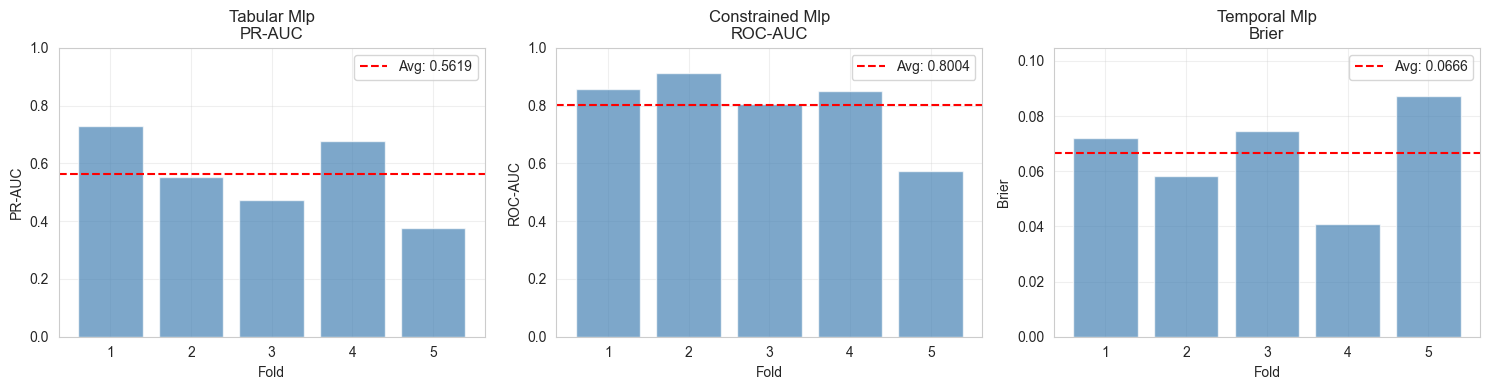

Plot saved to models/neural_comparison_pr_auc.png


In [14]:
# PR-AUC comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, metric) in enumerate([('tabular_mlp', 'PR-AUC'), ('constrained_mlp', 'ROC-AUC'), ('temporal_mlp', 'Brier')]):
    data = results[model_name]
    
    if metric == 'PR-AUC':
        vals = [d['pr_auc'] for d in data]
    elif metric == 'ROC-AUC':
        vals = [d['roc_auc'] for d in data]
    else:
        vals = [d['brier'] for d in data]
    
    axes[idx].bar(range(1, 6), vals, color='steelblue', alpha=0.7)
    axes[idx].axhline(y=np.mean(vals), color='red', linestyle='--', label=f'Avg: {np.mean(vals):.4f}')
    axes[idx].set_xlabel('Fold')
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{model_name.replace("_", " ").title()}\n{metric}')
    axes[idx].set_ylim([0, 1] if metric != 'Brier' else [0, max(vals) * 1.2])
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/neural_comparison_pr_auc.png', dpi=150, bbox_inches='tight')
plt.show()

print('Plot saved to models/neural_comparison_pr_auc.png')